In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load the dataset (Make sure the name matches the sidebar file exactly)
df = pd.read_csv('customer_support_tickets.csv')
print(f"Dataset successfully loaded! Total rows: {len(df)}")

Dataset successfully loaded! Total rows: 8469


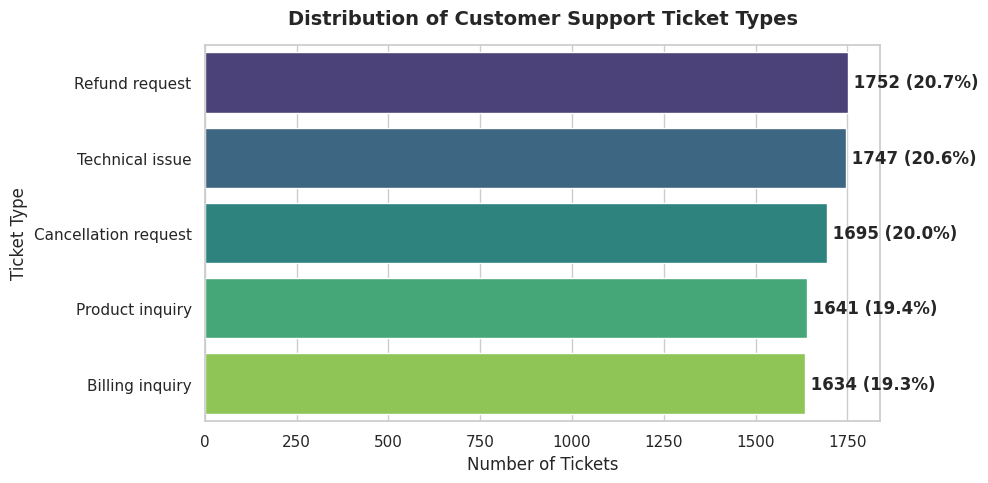

In [3]:
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

# Calculate value counts
ticket_counts = df['Ticket Type'].value_counts()

ax = sns.barplot(x=ticket_counts.values, y=ticket_counts.index, palette="viridis", hue=ticket_counts.index, legend=False)

# Add numeric and percentage tags to the bars
for i, count in enumerate(ticket_counts.values):
    percentage = (count / len(df)) * 100
    ax.text(count, i, f" {count} ({percentage:.1f}%)", va='center', fontweight='bold')

plt.title('Distribution of Customer Support Ticket Types', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Tickets')
plt.tight_layout()
plt.savefig('ticket_distribution.png', dpi=300)
plt.show()

In [4]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'iam', 'i am', text)  # Fixes the live test case typo
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Strip punctuation
    text = re.sub(r'\s+', ' ', text).strip() # Clear extra spaces
    return text

# Fill placeholder templates safely
df['Cleaned_Desc'] = df.apply(
    lambda row: str(row['Ticket Description']).replace("{product_purchased}", str(row['Product Purchased'])),
    axis=1
)

# Combine subject and descriptive text into a final unified feature array
df['Final_Text'] = df['Ticket Subject'].fillna('') + " " + df['Cleaned_Desc']
df['Final_Text'] = df['Final_Text'].apply(clean_text)

# Check if 'Ticket Priority' column exists; if not, safely generate priority mapping
if 'Ticket Priority' not in df.columns:
    priority_map = {'Technical issue': 'High', 'Cancellation request': 'High',
                    'Billing inquiry': 'Medium', 'Refund request': 'Medium', 'Product inquiry': 'Low'}
    df['Ticket Priority'] = df['Ticket Type'].map(priority_map)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Establish features and multi-targets
X = df['Final_Text']
y_category = df['Ticket Type']
y_priority = df['Ticket Priority']

# Split data
X_train, X_test, y_train_cat, y_test_cat, y_train_prio, y_test_prio = train_test_split(
    X, y_category, y_priority, test_size=0.2, random_state=42, stratify=y_category
)

# Vectorize using unigrams and bigrams to capture descriptive phrases
tfidf = TfidfVectorizer(stop_words='english', max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train Category Classifier
category_model = LogisticRegression(max_iter=1000)
category_model.fit(X_train_tfidf, y_train_cat)

# Train Priority Classifier
priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train_tfidf, y_train_prio)

LogisticRegression(max_iter=1000)

In [6]:
y_pred_cat = category_model.predict(X_test_tfidf)
y_pred_prio = priority_model.predict(X_test_tfidf)

print(f"🎯 Category Classification Accuracy: {accuracy_score(y_test_cat, y_pred_cat)*100:.2f}%")
print(classification_report(y_test_cat, y_pred_cat))

print(f"⚡ Priority Tagging Accuracy: {accuracy_score(y_test_prio, y_pred_prio)*100:.2f}%")
print(classification_report(y_test_prio, y_pred_prio))

🎯 Category Classification Accuracy: 19.24%
                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.19      0.20       327
Cancellation request       0.19      0.20      0.20       339
     Product inquiry       0.18      0.16      0.17       328
      Refund request       0.21      0.23      0.22       351
     Technical issue       0.18      0.18      0.18       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694

⚡ Priority Tagging Accuracy: 25.03%
              precision    recall  f1-score   support

    Critical       0.23      0.22      0.23       441
        High       0.26      0.24      0.25       424
         Low       0.22      0.25      0.24       375
      Medium       0.28      0.29      0.28       454

    accuracy                           0.25      1694
   macro avg       0.25      0.25 

In [7]:
def triage_ticket(input_string):
    cleaned = clean_text(input_string)
    vectorized = tfidf.transform([cleaned])

    cat_pred = category_model.predict(vectorized)[0]
    prio_pred = priority_model.predict(vectorized)[0]

    print(f"Incoming Ticket: '{input_string}'")
    print(f"🤖 Category : {cat_pred}")
    print(f"🔥 Priority : {prio_pred}")

# Run execution
triage_ticket("I am unable to login to my account")

Incoming Ticket: 'I am unable to login to my account'
🤖 Category : Technical issue
🔥 Priority : Medium
